# 🚲 Project 3: Bike Sharing Demand Predictor
### Dataset: Bike Sharing Demand Dataset (hour.csv / day.csv)
---

## 📋 Dataset Overview & Expected Target

| Feature | Description | Type |
|---------|-------------|------|
| `instant` | Row index | Drop |
| `dteday` | Date string | Parse → new features |
| `season` | 1=Spring, 2=Summer, 3=Fall, 4=Winter | Ordinal Categorical |
| `yr` | Year: 0=2011, 1=2012 | Binary Numerical |
| `mnth` | Month (1–12) | Cyclical Numerical |
| `hr` | Hour of day (0–23) | Cyclical Numerical |
| `holiday` | Whether day is a public holiday | Binary |
| `weekday` | Day of week (0=Sun … 6=Sat) | Cyclical Numerical |
| `workingday` | 1 if neither weekend nor holiday | Binary |
| `weathersit` | 1=Clear, 2=Mist, 3=Light rain, 4=Heavy rain | Ordinal |
| `temp` | Normalised temperature (÷41) | Numerical |
| `atemp` | Normalised "feels-like" temperature (÷50) | Numerical |
| `hum` | Normalised humidity (÷100) | Numerical |
| `windspeed` | Normalised wind speed (÷67) | Numerical |
| `casual` | Count of casual riders | ⚠️ DROP (leakage) |
| `registered` | Count of registered riders | ⚠️ DROP (leakage) |

> 🎯 **Target Variable → `cnt`** (total rentals = casual + registered)
> 📌 **Task Type → Regression (count prediction)**

> ⚠️ **Leakage Warning:** `casual` and `registered` are sub-components of `cnt`.
> Including them in `X` gives a perfect-but-meaningless model. **Always drop them.**

> 💡 **What makes this project different from the first two:** the rows are ordered in time,
> and several features are *circular*. Both facts change decisions you made on autopilot before —
> how you split, and how you encode. Those are the two things to get right here.

## 🧭 How to use this notebook

Every cell below is a **brief**, not a solution. Each one tells you:

- **Goal** — what this cell must produce when you're done
- **Hints** — which family of tools to reach for, and the trap to avoid
- **Check yourself** — how you'll know your output is right

No answer code is included on purpose. If you get stuck for more than ~10 minutes on a cell, look up the library docs first (`pandas`, `seaborn`, `scikit-learn` all have excellent ones), and only then ask for a nudge on that *specific* cell.

Variable names that later cells depend on are stated explicitly (e.g. `df`, `df_clean`, `X_train`). Stick to those names and the notebook stays coherent.

---
## ⚙️ Phase 1 — Environment & Data Loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)

warnings.filterwarnings("ignore")


TARGET = "cnt"
LEAKAGE_COLS = ["casual", "registered", "instant", "dteday"]

### 1.1 — Load the Dataset

In [18]:
FILE_PATH = "hour.csv"   

df = pd.read_csv(FILE_PATH)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


### 1.2 — Initial Inspection

In [19]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [21]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [22]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

### 2.1 — Target Variable Distribution

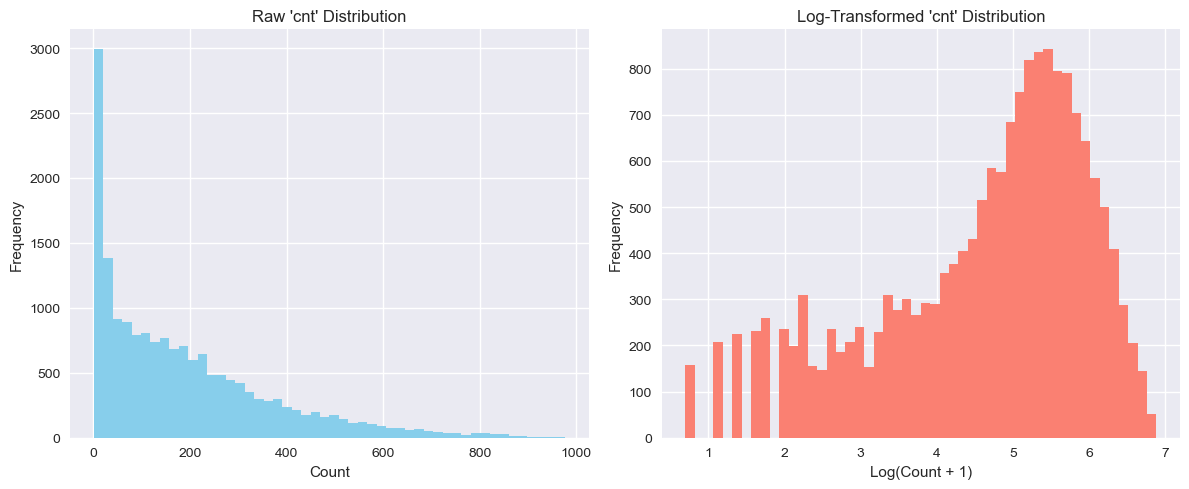

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[TARGET], bins=50, color="skyblue")
axes[0].set_title("Raw 'cnt' Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df[TARGET]), bins=50, color="salmon")
axes[1].set_title("Log-Transformed 'cnt' Distribution")
axes[1].set_xlabel("Log(Count + 1)")
axes[1].set_ylabel("Frequency")

fig.tight_layout()
plt.show()

### 2.2 — Hourly Rental Pattern (The Pivotal Plot)

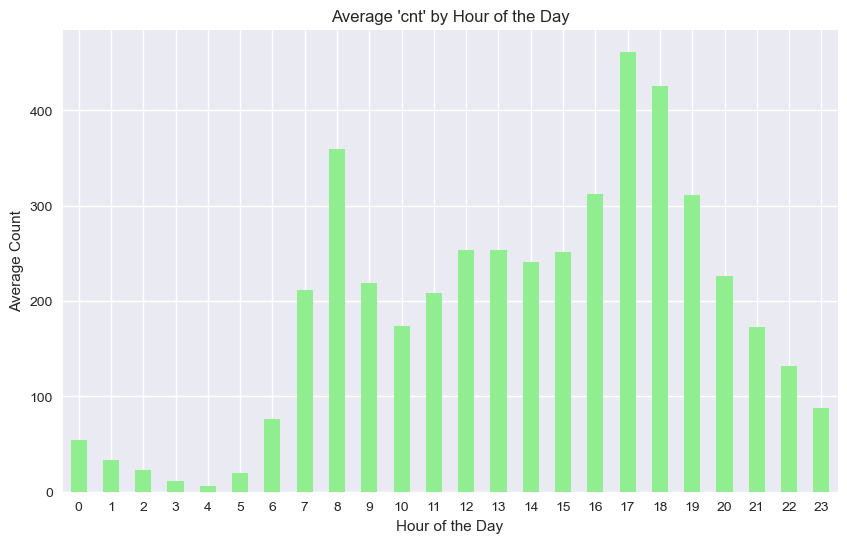

In [29]:
df.groupby("hr")[TARGET].mean().plot(kind="bar", color="lightgreen")
plt.title("Average 'cnt' by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.show()

### 2.3 — Seasonal and Monthly Patterns

In [ ]:
# GOAL: (a) a box plot of `cnt` by `season`, (b) a line chart of mean `cnt` by month.
#
# HINTS
#   - seaborn's boxplot takes data, x (the category) and y (the target).
#   - For the monthly chart, same groupby-then-plot idiom as 2.2.
#   - Remember season is coded 1=Spring, 2=Summer, 3=Fall, 4=Winter. Put that in
#     the title or the tick labels — future-you will not remember the mapping.
#
# ASK YOURSELF
#   - Which season is busiest? Is it the one you'd have guessed?
#   - The monthly curve rises and then falls. Does it come back down to where it
#     started, or is December noticeably higher than January? Section 2.9 explains
#     why, and it's not seasonality.
#   - `season` and `mnth` clearly carry overlapping information. Is keeping both
#     harmful, harmless, or helpful? Different answers for linear models and trees —
#     be able to say which and why.


### 2.4 — Weekday vs Weekend vs Holiday

In [ ]:
# GOAL: one box plot of `cnt` per category, for each of: weekday, workingday, holiday.
#
# HINTS
#   - Loop over the three column names, creating a NEW figure inside the loop, or
#     all three land on top of each other.
#
# ASK YOURSELF
#   - Do the medians differ much across the three? Less than you expected?
#   - Here's the subtlety: comparing total daily volume hides the real effect.
#     A commuter weekday and a leisurely Saturday can produce similar totals with
#     completely different SHAPES. The plot that reveals it is 2.8, not this one.
#   - `workingday` is almost a function of `weekday` and `holiday` combined.
#     Is that redundancy a problem? For which model family?
#
# GOING FURTHER
#   - The header cell said `casual` and `registered` must be dropped from X — but
#     nothing stops you from EXPLORING them here, before Phase 3. Plot mean casual
#     and mean registered by weekday on the same axes. The two rider types behave
#     almost oppositely, and it's the most interesting thing in this dataset.


### 2.5 — Weather Impact on Demand

In [ ]:
# GOAL: a box plot of `cnt` by `weathersit` (1=Clear → 4=Heavy rain).
#
# HINTS
#   - Same boxplot call as 2.4. Spell the weather codes out in the x-label.
#
# ASK YOURSELF
#   - Is the trend monotonic — does demand fall every step as weather worsens?
#   - Count the rows in category 4. (value_counts on the column.) How many are there?
#   - Given that count, how much do you trust the category-4 box? What could you
#     do about a category with a handful of observations — merge it into 3, leave
#     it alone, or drop those rows? Argue for one.


### 2.6 — Temperature vs Ridership

In [ ]:
# GOAL: a scatter of `temp` (x) against `cnt` (y), with points coloured by season.
#
# HINTS
#   - Either loop over the four season codes and call plt.scatter once per group
#     (which gives you control of the labels), or hand the whole DataFrame to
#     seaborn's scatter function with hue="season".
#   - Transparency plus small markers — with 17,000 points the default settings
#     produce a solid block of colour.
#
# ASK YOURSELF
#   - Is the relationship positive throughout, or does it flatten (or reverse) at
#     the hot end? Think about what riding in 35°C is actually like.
#   - `temp` and `atemp` are near-duplicates by construction. Confirm their
#     correlation in 2.7, then decide in Phase 3 whether to keep both.
#   - The vertical spread at any given temperature is enormous. What variable
#     explains most of that spread? (You plotted it in 2.2.)


### 2.7 — Correlation Heatmap

In [ ]:
# GOAL: a heatmap of the pairwise correlation matrix for the numerical columns.
#
# HINTS
#   - Select numeric columns by dtype, call the DataFrame correlation method, then
#     draw it with seaborn's heatmap. Annotations on, diverging colormap, two decimals.
#
# ⚠️ READ THE OUTPUT CAREFULLY
#   - `casual` and `registered` will show a very high correlation with `cnt`.
#     That is not a discovery — it's arithmetic, because they sum to it. This is
#     what leakage looks like on a heatmap, and it's your visual confirmation that
#     3.1 is mandatory.
#
# ASK YOURSELF
#   - Ignoring those two, which feature correlates most strongly with `cnt`?
#   - Now find `hr`. Its correlation is weak — near zero. But 2.2 showed hour is
#     the dominant driver of demand. Explain the contradiction. (What kind of
#     relationship does a correlation coefficient measure, and what kind did 2.2
#     show?) Getting this right is the single most valuable insight in the notebook,
#     and it's why you should never rank features by correlation alone.
#   - Which two FEATURES are most correlated with each other? What will you do
#     about it?


### 2.8 — Hour × Weekday Demand Heatmap

In [ ]:
# GOAL: a heatmap of mean `cnt` with weekday on one axis and hour on the other —
#       the full 7 × 24 demand matrix.
#
# HINTS
#   - DataFrame.pivot_table with values=TARGET, index="weekday", columns="hr" and
#     an aggregation function of mean builds the matrix in one call. Feed that
#     straight to seaborn's heatmap.
#   - Make the figure wide (24 columns) and pick a sequential colormap — this is
#     magnitude data, not divergence data.
#
# ASK YOURSELF
#   - Find the two bright vertical bands on weekdays. Now look at rows 0 and 6
#     (Sunday and Saturday). Where does the brightness go?
#   - Describe the weekend pattern in one sentence. How is it shaped differently
#     from the weekday one?
#   - So: is the effect of `hr` the same on every day of the week? If not, you've
#     just found an INTERACTION — hour × workingday. A linear model cannot express
#     it without help. Note it for 3.5; a tree can find it by splitting.


### 2.9 — Year-over-Year Growth

In [ ]:
# GOAL: mean `cnt` per month plotted for yr=0 (2011) and yr=1 (2012) on the same axes.
#
# HINTS
#   - Filter to one year, group by month, take the mean, plot; repeat for the other
#     year without creating a new figure so both lines share the axes. Label them.
#
# ASK YOURSELF
#   - Do the two curves have the same shape? Is one simply higher than the other?
#   - Roughly what percentage growth is that, year to year?
#   - Now the consequential question: the `yr` column is 0/1. Your model will learn
#     "year 1 means more riders". What does it predict for 2013 — a year it has
#     never seen and cannot represent? This is the reason you cannot deploy this
#     model forward in time as-is, and it's worth a sentence in your write-up.


---
## 🔧 Phase 3 — Data Preprocessing & Feature Engineering

In [ ]:
# GOAL: a working copy of the data named `df_clean`.
#
# HINTS
#   - Use the DataFrame method that returns an independent copy. Assigning
#     df_clean = df gives you a second name for the SAME object, and every edit
#     below would silently mutate your raw data.


### 3.1 — Drop Leakage & Irrelevant Columns

In [ ]:
# GOAL: df_clean with `casual`, `registered`, `instant` and `dteday` removed.
#
# HINTS
#   - Build the drop list by filtering LEAKAGE_COLS down to columns that actually
#     exist in df_clean, so the cell survives a switch to day.csv.
#   - Print the surviving column list afterwards and read it. Every column left
#     must be something you could genuinely know BEFORE the hour happened.
#
# WHY EACH ONE GOES
#   - casual + registered: they sum to the target. Knowing them means you already
#     know the answer. This is the definition of leakage.
#   - instant: a row counter. It correlates with time by accident and teaches the
#     model nothing transferable.
#   - dteday: a raw date string. No model accepts it as text.
#
# ASK YOURSELF — and this one is a real decision
#   - Everything in `dteday` is already encoded elsewhere (yr, mnth, weekday, holiday).
#     Almost. What about the DAY of the month, or a "days since the programme
#     started" counter? Would either help? Would the second one just be `instant`
#     wearing a hat? If you want to extract something, do it BEFORE the drop.


### 3.2 — Handle Missing Values

In [ ]:
# GOAL: confirm on df_clean that there are no nulls; add an imputation strategy
#       only if there are.
#
# HINTS
#   - Same null-count idiom as Phase 1.
#   - If you ever DID find nulls in a time series: the median of the whole column
#     is a poor fill, because demand at 3am and 6pm come from different worlds.
#     Forward-fill or an hour-specific median is the honest choice. Never compute
#     a fill value from data that lies in the future of the row you're filling.
#
# NOTE
#   - This dataset is typically complete. The cell stays because a pipeline that
#     doesn't check is a pipeline that breaks on the next dataset.


### 3.3 — Cyclical Feature Encoding

Hour (0–23), month (1–12), and weekday (0–6) are **circular** — hour 23 and hour 0 are one hour apart, but as raw integers they sit at opposite ends of the range.

**Sine/cosine encoding** maps each cycle onto a unit circle, so that the last value and the first value land next to each other.

| Feature | Period |
|---------|--------|
| `hr` | 24 |
| `mnth` | 12 |
| `weekday` | 7 |

The formula for one feature `v` with period `p` is a pair of columns: the sine and the cosine of `2π · v / p`.

In [ ]:
# GOAL: two new columns per cyclical feature — hr_sin/hr_cos, mnth_sin/mnth_cos,
#       weekday_sin/weekday_cos — in df_clean.
#
# HINTS
#   - numpy gives you pi, sin and cos. The whole thing is one arithmetic expression
#     per column, applied to the Series.
#   - ⚠️ Always create BOTH sin AND cos. One alone is ambiguous: sin is identical
#     for hour 6 and hour 18. Convince yourself of that by evaluating both before
#     you move on — it's a 30-second check that makes the concept stick.
#
# CHECK YOURSELF
#   - Compute the encoding for hr = 23 and for hr = 0. The two (sin, cos) points
#     should be close together. Then compare hr = 0 and hr = 12 — they should be
#     as far apart as the circle allows. If that isn't what you see, your period
#     is wrong.
#   - Print the shape. Six new columns.
#
# YOUR DECISION — keep or drop the raw integer columns?
#   - Trees split on thresholds, so raw `hr` is perfectly usable for them, and in
#     practice often BETTER than sin/cos (a tree can isolate hour 8 exactly; the
#     smooth encoding makes it work harder).
#   - Linear models genuinely need the circular version.
#   - You can't satisfy both with one feature set unless you keep everything.
#     Decide, write down why, and note it — because in 4.10 you'll be comparing
#     model families that wanted different things from you.


### 3.4 — Encode Ordinal Categoricals (Optional)

In [ ]:
# GOAL: decide whether `season` and `weathersit` stay as integers or become
#       indicator columns — and act on your decision.
#
# THE ARGUMENT BOTH WAYS
#   - Both are already 1–4 integers with a natural ORDER (weather genuinely gets
#     worse; seasons follow each other). Leaving them alone is defensible.
#   - But integer coding also asserts equal SPACING — that the drop from clear to
#     mist equals the drop from mist to light rain. Look back at your 2.5 box plot.
#     Is that true?
#   - One-hot removes the spacing assumption at the cost of extra columns and of
#     the ordering information.
#
# HINTS
#   - pandas has a top-level function that turns categorical columns into dummy
#     indicators in one call; pass the columns argument, and read about drop_first.
#   - If the new columns come out as True/False, sklearn accepts that; cast to int
#     if it bothers you.
#
# ASK YOURSELF
#   - Which model family cares about this choice more, and why?
#   - Try it both ways once the notebook runs end to end. Two honest runs beat
#     an hour of reasoning.


### 3.5 — Additional Feature Engineering

In [ ]:
# GOAL: at least two domain-informed features in df_clean, built from what you
#       actually saw in Phase 2.
#
# CANDIDATES — take these as starting points, not as a checklist
#   - A rush-hour flag: 1 for the commute hours you identified in 2.2. It hands a
#     linear model, in one column, the thing the hourly curve was screaming about.
#   - The interaction you found in 2.8: hour behaves differently on working days.
#     Multiplying `workingday` by an hour-derived column lets a linear model apply
#     a different hourly effect on working days. (Same trick as the smoker
#     interaction in Project 2 — a product term switches an effect on and off.)
#   - A comfort index: warm and dry is pleasant, warm and humid is not. Something
#     like temp × (1 − hum) captures it in one number.
#   - A wind-chill proxy along the same lines with windspeed.
#
# HINTS
#   - The isin method plus astype(int) turns "is this hour in my list" into a 0/1
#     column in one line.
#   - Column-wise arithmetic on two Series is exactly what you'd guess.
#
# ASK YOURSELF
#   - Trees can discover every one of these on their own, given enough depth and
#     data. So who are you really building them for?
#   - Predict now which of your new columns will rank highest in 4.10. Then check.
#     Being wrong here is more instructive than being right.
#
# CHECK YOURSELF
#   - Print the shape and the head. Spot-check a few rows by hand: is the rush-hour
#     flag actually 1 at 8am and 0 at 3am?


### 3.6 — (Optional) Target Transformation

In [ ]:
# GOAL: decide — and act on — whether to model `cnt` directly or its
#       log-transformed version.
#
# THE CASE FOR IT
#   - Go back to your histograms in 2.1. Count data is right-skewed and its variance
#     grows with its mean; the linear family assumes roughly constant error across
#     the range. The log transform is the standard fix.
#   - Use the numpy log function that adds one first — you may well have zero-rental
#     hours, and log(0) is negative infinity.
#
# ⚠️ THE TRAP — read this twice
#   - If you transform the target, every prediction comes out in LOG RIDES. An RMSE
#     of 0.4 log-rides means nothing to a human and cannot be compared against a run
#     where you didn't transform.
#   - Before computing metrics in 4.9, invert BOTH y_test and the predictions with
#     the numpy inverse of log1p, so your errors are back in rides.
#   - Miss that step and you'll "improve" your RMSE by a factor of hundreds and
#     believe it. This is the single most common self-inflicted wound in this project.
#
# ⚠️ SECOND TRAP, SPECIFIC TO COUNTS
#   - Whatever you do, a regressor can and will predict NEGATIVE rentals for quiet
#     hours. Negative bikes do not exist. Clipping predictions at zero before scoring
#     is legitimate and usually improves every metric. Decide whether you're doing
#     it, and apply it consistently to every model or to none.
#
# SUGGESTION
#   - Run the notebook once WITHOUT the transform, record the numbers, then once
#     WITH it. Comparing two honest runs teaches more than guessing.


---
## 🤖 Phase 4 — Model Training & Evaluation

### 4.1 — X / y Split

In [ ]:
# GOAL: `X` = every predictor column, `y` = the target column.
#
# HINTS
#   - X is df_clean with the target dropped; y is that column on its own.
#   - Print both shapes.
#
# CHECK YOURSELF
#   - Read X's column list out loud. Is `casual` or `registered` in there? Is
#     anything else derived from the target? If your R² later comes out above
#     0.99, come back to this cell first — that is what leakage looks like from
#     the other end.


### 4.2 — Train / Test Split

> ⚠️ **This is time-series data.** The rows are in chronological order, and a random split
> puts *future* hours in your training set while it tests you on *past* ones.
>
> **Option A (random)** — what `train_test_split` does by default. Optimistic, and technically cheating.
> **Option B (chronological)** — split at a point in time: everything before it trains, everything after it tests.
>
> Do Option B. Then, if you're curious, do Option A too and compare the scores — the gap between them
> is the size of the lie.

In [ ]:
# GOAL: X_train, X_test, y_train, y_test.
#
# HINTS — Option B (the one to do)
#   - Compute a cutoff index at, say, 80% of the row count, then take positional
#     slices of X and y on either side of it. .iloc is the positional indexer.
#   - No shuffling, no random_state. The order IS the information.
#
# HINTS — Option A (for the comparison)
#   - train_test_split is imported and returns the four pieces in that exact order.
#     Fix a random_state so re-runs are comparable.
#
# ⚠️ ONE PRECONDITION
#   - A chronological slice is only chronological if the DataFrame is still in date
#     order. If you sorted or shuffled anywhere above, this silently breaks. Verify
#     before you slice.
#
# CHECK YOURSELF
#   - Print all four shapes; train rows + test rows must equal the total.
#   - Now the interesting check: compare y_train.mean() against y_test.mean().
#     With a chronological split on this dataset they will NOT be close. Why not?
#     (Look back at 2.9.) What does that imply about the test scores you're about
#     to get — and is a model that has never seen 2012 being asked something fair?


### 4.3 — (Optional) Feature Scaling

In [ ]:
# GOAL: X_train_scaled and X_test_scaled.
#
# WHO NEEDS THIS
#   - Linear / Ridge: yes. Ridge penalises coefficient size, so features on wildly
#     different scales get penalised unequally. Note that temp, hum and windspeed
#     already arrive in [0, 1], but `hr` runs to 23 and your engineered columns
#     could be anything — so the scales are not uniform.
#   - Random Forest / Gradient Boosting: no. Trees split on thresholds and don't
#     care about units. Feed them the raw X_train, and you keep the column names
#     you'll want in 4.10.
#
# HINTS
#   - StandardScaler is imported. One method learns the statistics and transforms
#     at once; another only transforms.
#
# ⚠️ THE RULE YOU MUST NOT BREAK
#   - Learn the statistics from the TRAINING data only, then apply them to the test
#     data. Which method goes on which set is the whole point of this cell.
#   - It matters more here than it did in Project 2: your test set is the FUTURE.
#     Letting the scaler see it means letting the past learn from the future.


### 4.4 — Baseline: Linear Regression

In [ ]:
# GOAL: a fitted LinearRegression named `lr_model` and its test-set predictions
#       named `lr_preds`.
#
# HINTS
#   - Construct, fit on training data, predict on test data. Every sklearn model
#     below is the same three lines with a different constructor.
#   - Use the SCALED features.
#
# WHY A BASELINE
#   - This is the number every fancier model has to beat.
#
# ASK YOURSELF
#   - Predict the outcome before you run it. Demand as a function of hour is a
#     two-humped curve; a linear model fits a straight line to each feature. Do
#     you expect this to do well?
#   - Check the minimum of lr_preds. Negative? Of course it is — see the second
#     trap in 3.6.


### 4.5 — Ridge Regression

In [ ]:
# GOAL: `ridge_model` and `ridge_preds`.
#
# THE CONCEPT
#   - Ridge = linear regression + an L2 penalty on coefficient size. It shrinks
#     coefficients toward zero (never exactly to zero), which stabilises things
#     when features are correlated — and yours are, by construction: temp/atemp,
#     season/mnth, and every sin/cos pair you built.
#
# HINTS
#   - The only argument you need is alpha, the penalty strength.
#   - YOUR EXPERIMENT: try 0.1, 1.0, 10, 100 and record the test R² for each.
#     Does it peak in the middle, or barely move?
#   - Scaled features, as in 4.4.
#
# ASK YOURSELF
#   - If Ridge and plain Linear Regression score nearly identically, what does that
#     tell you? (Hint: with ~14,000 training rows and ~20 features, is overfitting
#     really the binding constraint on a linear model here?)


### 4.6 — Random Forest Regressor

In [ ]:
# GOAL: `rf_model` and `rf_preds`.
#
# THE CONCEPT
#   - Many decision trees, each grown on a bootstrap sample of rows and a random
#     subset of features, averaged. Splitting on thresholds is exactly what the
#     hour-of-day curve needs: a tree can carve out "hour is between 7 and 9"
#     without any help from you.
#
# HINTS
#   - ⚠️ Fit on the RAW X_train, not the scaled version.
#   - YOUR DECISIONS: n_estimators (100 is a fine start), max_depth (None grows
#     until pure — on 14,000 rows that will overfit; try capping it), random_state.
#
# ASK YOURSELF
#   - Score on the TRAINING set as well as the test set. A big gap is overfitting;
#     lower max_depth or raise min_samples_leaf and watch the gap close.
#   - Expect this model to beat the linear ones by a wide margin. Before you look
#     at the number, write down WHY in one sentence — the answer is in your 2.2
#     and 2.8 plots, not in the algorithm.


### 4.7 — Gradient Boosting Regressor

In [ ]:
# GOAL: `gb_model` and `gb_preds`.
#
# THE CONCEPT
#   - Where a forest builds trees in parallel and averages them, boosting builds
#     them in sequence: each new tree is trained on the errors the ensemble has
#     made so far. Usually the strongest model on tabular data this size.
#
# HINTS
#   - Raw (unscaled) X_train again.
#   - YOUR DECISIONS: n_estimators, learning_rate, max_depth, random_state.
#   - learning_rate and n_estimators trade off: a smaller rate needs more trees to
#     reach the same place but usually generalises better. Shallow trees (depth 3–5)
#     are normal — boosting wants many weak learners, not a few strong ones.
#
# ASK YOURSELF
#   - Try (0.1, 100 trees) against (0.05, 300 trees). Which wins, and how much
#     longer did it take to fit? Is the improvement worth the wall-clock time?


### 4.8 — Evaluation Helper Function

In [ ]:
# GOAL: a function `evaluate_model(name, y_true, y_pred)` that prints MSE, RMSE,
#       MAE, RMSLE and R², and returns them in a dict so 4.9 can build a table.
#
# HINTS
#   - All the metrics you need are imported; RMSE is the square root of MSE.
#   - RMSLE is the one new metric in this project: take log1p of both arrays, then
#     compute RMSE on those. ⚠️ log1p of a negative prediction is undefined — clamp
#     both arrays at zero first (numpy's maximum against 0 does it elementwise).
#   - Return {"Model": name, "MSE": ..., "RMSE": ..., "MAE": ..., "RMSLE": ...,
#     "R2": ...} so a list of these goes straight into a DataFrame.
#   - f-string format specs (thousands separators, fixed decimals) make the output
#     readable. Worth ten minutes.
#
# KNOW WHAT YOU'RE PRINTING
#   - RMSE is in rides. It punishes large errors hardest, so the busy evening peak
#     dominates it.
#   - MAE is the average error in rides, all errors weighted equally. RMSE much
#     larger than MAE means a few big misses are driving the score.
#   - RMSLE measures RELATIVE error. Missing by 20 rides at 3am (when actual is 5)
#     is a catastrophe proportionally; missing by 20 at 6pm (when actual is 500)
#     is nothing. RMSE cannot tell those apart; RMSLE can. It's the standard metric
#     for demand forecasting, and it's why it's here.
#   - R² is the share of variance explained. 1.0 perfect, 0.0 no better than the
#     mean, and it can go negative.
#   - ⚠️ If you log-transformed in 3.6, invert both arguments back to rides BEFORE
#     calling this.
#
# THEN
#   - Build a list called `results` and append one call per fitted model.


### 4.9 — Model Comparison Table

In [ ]:
# GOAL: one DataFrame, one row per model, sorted best-first.
#
# HINTS
#   - Your `results` list of dicts goes straight into the DataFrame constructor.
#     Set the model name as the index and sort by RMSLE ascending.
#
# ASK YOURSELF
#   - Do RMSE and RMSLE rank the models in the SAME order? If not, you've found
#     something real: one model is better on busy hours, another on quiet ones.
#     Which would you deploy, and what would you need to know about the business
#     to answer that?
#   - How much did your engineered features from 3.5 buy each family? Comment them
#     out, re-run, compare. That controlled experiment is the most valuable thing
#     you'll do in this notebook.
#   - Is the winner's margin larger than the noise? 4.12 is how you find out.


### 4.10 — Feature Importance (Random Forest)

In [ ]:
# GOAL: a horizontal bar chart of the forest's top ~15 feature importances.
#
# HINTS
#   - A fitted forest exposes its importances as an attribute, in the same order
#     as the training columns. Wrap it in a pandas Series indexed by X_train.columns
#     so the bars are labelled — this is exactly why 4.6 used the raw DataFrame.
#   - Sort, take the tail after sorting ascending (or the head after descending),
#     and plot with a horizontal bar kind.
#
# ASK YOURSELF
#   - Is an hour-derived feature at the top? Does the ranking match what 2.2 and
#     2.7 predicted — including the part where the correlation heatmap was misleading?
#   - If you kept BOTH raw `hr` and hr_sin/hr_cos, look at how the importance is
#     divided between them. Correlated features SPLIT their importance, so three
#     columns encoding one fact can each look modest while the fact itself dominates.
#     That's a known failure mode of this chart, not a discovery about hours.
#   - Where did `temp` and `atemp` land relative to each other? Same story.
#   - Worth looking up: sklearn's permutation_importance is slower and more honest
#     than the impurity-based version you just plotted.


### 4.11 — Actual vs Predicted Over Time

In [ ]:
# GOAL: a line chart overlaying actual and predicted values for the first ~200
#       test samples.
#
# HINTS
#   - Plot y_test's values and the predictions on the same axes; make one dashed
#     so they're distinguishable, and add a legend.
#   - 200 hourly samples is roughly 8 days — enough to see several daily cycles
#     without turning into mush.
#
# HOW TO READ IT
#   - Does the prediction reproduce the daily rhythm — right peaks at the right hours?
#   - Look at the peak HEIGHTS specifically. Models trained on squared error
#     systematically shave the tops off peaks, because under-shooting an extreme is
#     cheaper on average than over-shooting a typical hour. Do you see that here?
#   - Are there whole days where the model is wrong in the same direction throughout?
#     Check the weather and holiday flags for those days. A model that misses
#     rain-affected days is telling you something about your feature set.
#
# GOING FURTHER
#   - Plot residuals (actual − predicted) against predicted values. If the spread
#     widens as predictions grow, that's heteroscedasticity — and the statistical
#     argument for the log transform in 3.6.


### 4.12 — Mean Absolute Error by Hour of Day

In [ ]:
# GOAL: a bar chart of mean absolute error for each hour of the day.
#
# HINTS
#   - Copy X_test, attach three columns: the actual values, the predictions, and
#     the absolute difference between them. Then group by "hr" and take the mean
#     of the error column.
#   - ⚠️ This only works if `hr` survived into X_test as a raw column. If you
#     dropped it in favour of sin/cos in 3.3, you'll need to recover the hour —
#     from the original df by index, or by inverting the encoding with arctan2.
#     Getting bitten by this is a good lesson about dropping columns you still
#     want for analysis.
#
# ASK YOURSELF
#   - Which hours have the largest absolute error? Are they the busiest hours?
#   - Now normalise: divide each hour's mean error by that hour's mean actual count.
#     Does the ranking change completely? Which of the two charts would you show
#     an operations manager who has to decide where to station bikes, and why?
#   - This is the same RMSE-versus-RMSLE tension from 4.8, made visual. If you can
#     explain this chart clearly, you understand the metric choice.


### 4.13 — Cross-Validation

In [ ]:
# GOAL: cross-validated R² for your best model — mean and standard deviation
#       across folds — computed BOTH ways.
#
# HINTS
#   - cross_val_score takes an UNFITTED estimator, the full X and y, a cv value and
#     a scoring string, and returns one score per fold.
#   - Standard 5-fold: pass cv=5. Every fold trains on a mixture of past and future.
#   - TimeSeriesSplit is imported. Pass an instance as cv instead. It always trains
#     on earlier rows and tests on later ones, growing the training window each fold.
#   - Report mean ± std for both, not just the mean.
#
# THE POINT OF THIS CELL
#   - Compare the two numbers. The plain 5-fold score will be noticeably higher.
#     That gap is not noise — it is the amount by which random splitting flatters
#     a time-series model, and it's the single most important number in the notebook.
#   - The TimeSeriesSplit std is usually larger too. Why would the fold-to-fold
#     variation be bigger when folds are chronological? (Think about what's different
#     between the first fold's test period and the last one's.)
#
# ⚠️ CAUTION
#   - If you scaled features before this cell, the scaler has already seen every
#     fold's test data. The correct fix is an sklearn Pipeline wrapping the scaler
#     and the model, passed to cross_val_score. Look it up — it's the natural next
#     thing to learn after this notebook.


---
## ✅ Wrap-Up

You're done when you can answer these without scrolling up:

1. Which feature dominates demand, and why did the correlation heatmap fail to show it?
2. What does sine/cosine encoding fix, and which of your models actually needed it?
3. How much higher was your random-split score than your chronological one, and which number would you put in a report?
4. RMSE and RMSLE — did they pick the same winner? If not, which would you deploy on and why?
5. Where does your best model fail hardest, and what would you add to the feature set to fix it?

If a question is hard to answer, the fix is usually a plot you skipped — not a model you haven't tried yet.

### Optional extensions

- Wrap preprocessing and the model in an sklearn **Pipeline**, then tune with `GridSearchCV` using a `TimeSeriesSplit` as the cv.
- Try a **Poisson regressor** (`sklearn.linear_model.PoissonRegressor`) — a model built for count targets, rather than log-transforming and hoping.
- Build **lag features**: demand one hour ago, 24 hours ago, one week ago. On real forecasting problems these usually beat every weather feature combined. Think hard about which lags you'd actually have available at prediction time.
- Model `casual` and `registered` **separately** and add the two predictions. Section 2.4 suggested why that might beat modelling the total directly.
- Add **XGBoost** or **LightGBM** and see whether they beat Gradient Boosting here.